# Cell 1 — Install

In [1]:
!pip install -q ultralytics lap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.0 MB/s eta 0:00:00


# Cell 2 — Imports

In [2]:
import cv2
import time
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Cell 3 — Video

In [3]:
video_path = "Test.mp4"

# Cell 4 — Tracking Function

In [5]:
def run_tracking(model_name, output_name):

    model = YOLO(model_name)

    cap = cv2.VideoCapture(video_path)

    fps_video = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    out = cv2.VideoWriter(
        output_name,
        fourcc,
        fps_video,
        (width, height)
    )

    frame_count = 0

    start_time = time.time()

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        results = model.track(
            frame,
            persist=True,
            tracker="bytetrack.yaml",
            verbose=False
        )

        annotated_frame = results[0].plot()

        out.write(annotated_frame)

        frame_count += 1

    end_time = time.time()

    cap.release()
    out.release()

    processing_time = end_time - start_time

    fps = frame_count / processing_time

    avg_time = (processing_time / frame_count) * 1000

    print(f"Model: {model_name}")
    print(f"Frames: {frame_count}")
    print(f"Processing Time: {processing_time:.3f} sec")
    print(f"FPS: {fps:.3f}")
    print(f"Average Processing Time: {avg_time:.3f} ms")

    return {
        "Model": model_name.replace(".pt", ""),
        "Frames": frame_count,
        "Processing Time (sec)": processing_time,
        "FPS": fps,
        "Avg Processing Time (ms)": avg_time
    }

# Cell 5 — YOLOv10n

In [6]:
result10 = run_tracking(
    "yolov10n.pt",
    "YOLOv10n_tracking.mp4"
)

Model: yolov10n.pt
Frames: 942
Processing Time: 27.784 sec
FPS: 33.904
Average Processing Time: 29.495 ms


# Cell 6 — YOLO11n

In [7]:
result11 = run_tracking(
    "yolo11n.pt",
    "YOLOv11n_tracking.mp4"
)

Model: yolo11n.pt
Frames: 942
Processing Time: 33.127 sec
FPS: 28.436
Average Processing Time: 35.166 ms


# Cell 7 — YOLO12n

In [8]:
result12 = run_tracking(
    "yolo12n.pt",
    "YOLOv12n_tracking.mp4"
)

Model: yolo12n.pt
Frames: 942
Processing Time: 34.606 sec
FPS: 27.221
Average Processing Time: 36.737 ms


# Cell 8 — Results Table

In [9]:
results = pd.DataFrame([
    result10,
    result11,
    result12
])

results = results.round(3)

results

,Model,Frames,Processing Time (sec),FPS,Avg Processing Time (ms)
0,yolov10n,942,27.784,33.904,29.495
1,yolo11n,942,33.127,28.436,35.166
2,yolo12n,942,34.606,27.221,36.737


# Cell 9 — Real-Time Capability

In [12]:
results["Real-Time Capable"] = results["FPS"] >= 30

results

,Model,Frames,Processing Time (sec),FPS,Avg Processing Time (ms),Real-Time Capable
0,yolov10n,942,27.784,33.904,29.495,True
1,yolo11n,942,33.127,28.436,35.166,False
2,yolo12n,942,34.606,27.221,36.737,False


# Cell 10 — Best Model

In [13]:
best_model = results.loc[results["FPS"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best FPS:", best_model["FPS"])
print("Processing Time:", best_model["Processing Time (sec)"], "seconds")

Best Model: yolov10n
Best FPS: 33.904
Processing Time: 27.784 seconds


# Cell 11 — FPS Comparison

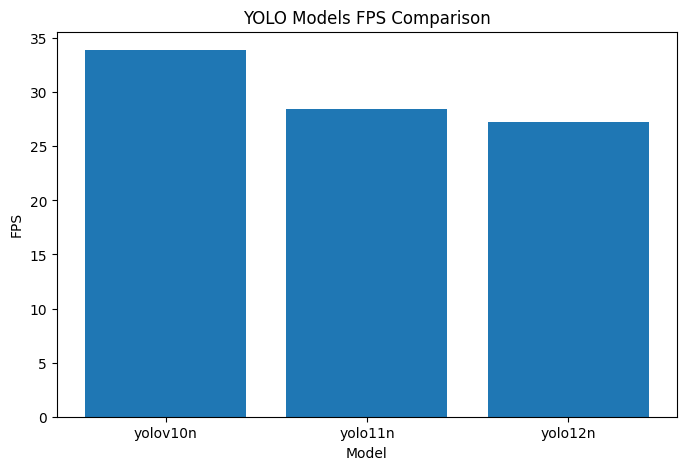

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["FPS"])

plt.title("YOLO Models FPS Comparison")
plt.xlabel("Model")
plt.ylabel("FPS")

plt.show()

# Cell 12 — Processing Time Comparison

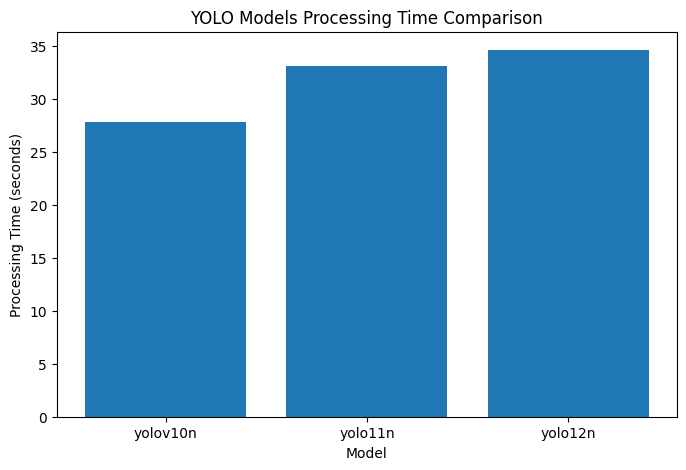

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Processing Time (sec)"]
)

plt.title("YOLO Models Processing Time Comparison")
plt.xlabel("Model")
plt.ylabel("Processing Time (seconds)")

plt.show()

# Cell 13 — Average Processing Time Comparison

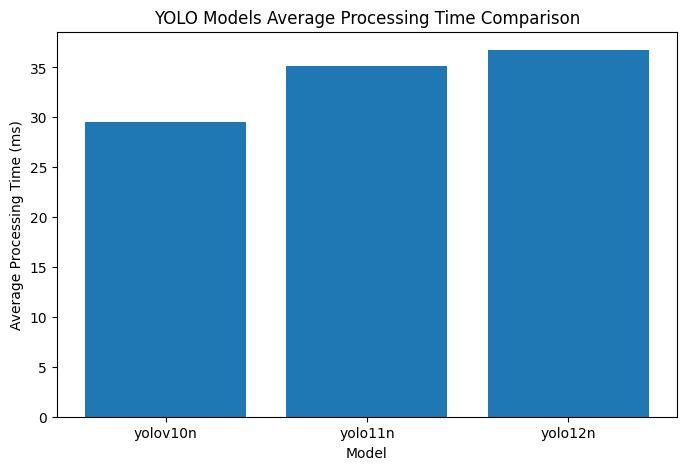

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Avg Processing Time (ms)"]
)

plt.title("YOLO Models Average Processing Time Comparison")
plt.xlabel("Model")
plt.ylabel("Average Processing Time (ms)")

plt.show()

# Cell 14 — Save Results

In [17]:
results.to_csv("YOLO_tracking_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
